In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1번

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%config InlineBackend.figure_format = "retina"

# 시각화 그래프 한글설정
from matplotlib.font_manager import FontProperties, fontManager
font_path = r"C:\Users\Admin\Downloads\JMK체.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path, size=12)
font_name = font_prop.get_name()

plt.rc('font', family=font_name)
plt.rc('font', size=12)
plt.rc('axes', unicode_minus=False)

In [3]:
# csv load
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')

In [4]:
# 데이터 프레임 결측치 확인
df_first.isna().sum()

지역          0
2013년12월    0
2014년1월     0
2014년2월     0
2014년3월     0
2014년4월     0
2014년5월     0
2014년6월     0
2014년7월     0
2014년8월     0
2014년9월     0
2014년10월    0
2014년11월    0
2014년12월    0
2015년1월     0
2015년2월     0
2015년3월     0
2015년4월     0
2015년5월     0
2015년6월     0
2015년7월     0
2015년8월     0
dtype: int64

In [5]:
# set_index
df_first.set_index('지역', inplace=True)

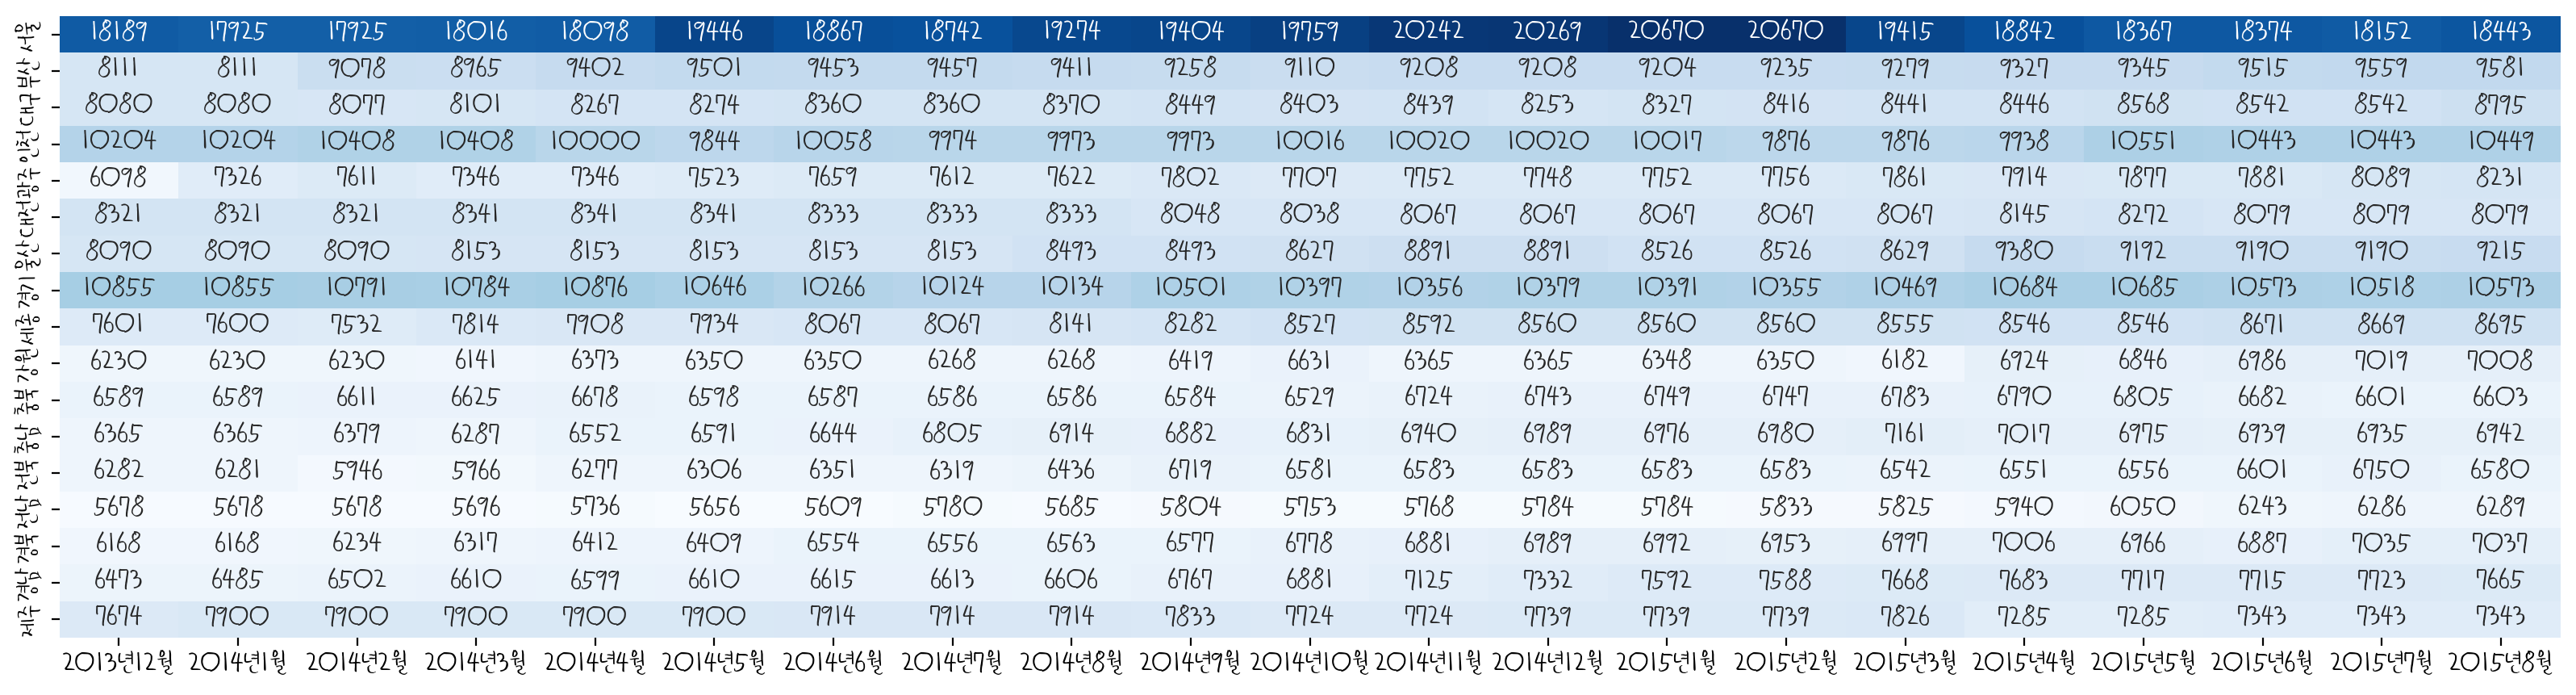

In [6]:
# heatmap 시각화
plt.figure(figsize=(20,5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.ylabel(None)
plt.show()

# 2번

In [18]:
# csv load
df_last = pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (1).csv', encoding='cp949')

In [19]:
df_last.isna().sum()

지역명                 0
규모구분                0
연도                  0
월                   0
분양가격(제곱미터당 천원)    845
dtype: int64

In [22]:
makenan = pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerce')
nan_idx = makenan[makenan.isna()].index
df_last.loc[nan_idx, '분양가격(제곱미터당 천원)'].unique()

array(['  ', nan, ' ', '-'], dtype=object)

In [25]:
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()=='']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,
29,광주,전용면적 102제곱미터초과,2015,10,
34,대전,전용면적 102제곱미터초과,2015,10,
81,제주,전용면적 60제곱미터이하,2015,10,
113,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,11,
...,...,...,...,...,...
8833,경남,전용면적 85제곱미터초과 102제곱미터이하,2024,5,
8836,제주,전용면적 60제곱미터이하,2024,5,
8838,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,5,
8964,울산,전용면적 102제곱미터초과,2024,7,


In [26]:
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()=='-']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
8861,대구,전용면적 60제곱미터이하,2024,6,-
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-


In [27]:
# 함수 정의
def change_float(row):
    row = row.copy()
    price = row['분양가격(제곱미터당 천원)']
    
    if pd.isna(price):
        row['분양가격(제곱미터당 천원)'] = np.nan
        
    elif price.strip() == '' or price == '-':
        row['분양가격(제곱미터당 천원)'] = np.nan
        
    elif price.find(',') != -1:
        row['분양가격(제곱미터당 천원)'] = float(price.replace(',',''))
        
    else:
        row['분양가격(제곱미터당 천원)'] = float(price)
        
    return row

In [29]:
# apply 적용
df_last = df_last.apply(change_float, axis=1)

In [34]:
df_last[df_last['분양가격(제곱미터당 천원)'].isna()].head()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,NaN
29,광주,전용면적 102제곱미터초과,2015,10,NaN
34,대전,전용면적 102제곱미터초과,2015,10,NaN
81,제주,전용면적 60제곱미터이하,2015,10,NaN
113,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,11,NaN


In [35]:
# 평당분양가격 칼럼 추가
df_last['평당분양가격'] = df_last['분양가격(제곱미터당 천원)'] * 3.3

In [37]:
# 그 외 이미지 상 변경 점 수정
df_last['규모구분'].unique()

array(['모든면적', '전용면적 60제곱미터이하', '전용면적 60제곱미터초과 85제곱미터이하',
       '전용면적 85제곱미터초과 102제곱미터이하', '전용면적 102제곱미터초과'], dtype=object)

In [38]:
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','').str.replace('이하','').str.replace('제곱미터','m²').str.replace(' ','').str.replace('초과','~')

In [44]:
df_last = df_last.drop(['규모구분','분양가격(제곱미터당 천원)'], axis=1)

In [45]:
columns = df_last.pop('전용면적')
df_last.insert(1, '전용면적', columns)

In [46]:
df_last

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,60m²,2015,10,18651.6
2,서울,60m²~85m²,2015,10,19410.6
3,서울,85m²~102m²,2015,10,18879.3
4,서울,102m²~,2015,10,19400.7
...,...,...,...,...,...
10875,제주,모든면적,2026,5,14760.9
10876,제주,60m²,2026,5,NaN
10877,제주,60m²~85m²,2026,5,14800.5
10878,제주,85m²~102m²,2026,5,NaN


# 3번

In [50]:
# groupby
df_last.groupby(['연도','지역명'])['평당분양가격'].mean().sort_values().unstack().round(1)

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.1,11060.9,8459.2,7464.2,7916.7,9018.9,8190.6,10377.4,20315.7,8765.0,9367.6,10976.0,6798.9,7110.4,7951.1,7689.9,6828.8
2016,7162.9,11685.0,8496.7,7753.4,9190.7,10282.0,8910.7,10743.5,21753.4,8857.8,9582.6,11099.1,6936.6,6906.6,9567.5,7958.2,7133.3
2017,7318.8,12296.2,8806.6,8288.1,9599.7,12192.0,9912.9,11637.6,21864.1,9132.9,10630.2,11672.4,7413.2,7406.1,12628.5,8157.3,7462.6
2018,8219.3,14258.4,9327.7,8680.8,9527.0,12139.3,10234.1,12890.0,23202.2,10340.5,10241.4,11881.5,7929.8,8174.6,11936.0,8201.8,8149.3
2019,8934.5,15665.5,10697.6,9050.2,12111.7,14081.6,12619.2,13537.9,28286.8,11299.4,10216.2,13249.8,8219.3,8532.3,11828.5,8748.8,7970.9
2020,10302.4,15106.1,10919.3,9997.7,13406.5,15314.2,11238.8,13353.0,29781.0,11628.1,12837.6,14983.0,9562.4,8559.4,14192.9,9139.4,8359.0
2021,10291.3,14567.1,11302.3,11227.2,13709.8,15586.3,11994.2,14317.7,29380.4,12578.1,14192.0,15774.3,9980.8,9047.9,22302.3,9860.7,8822.4
2022,11644.2,16621.6,12455.7,12018.0,15095.9,16821.9,14113.9,18166.8,29128.5,11310.0,17903.8,17341.8,10635.5,10003.1,18953.8,11730.3,10033.5
2023,13409.4,20175.2,13283.2,13025.3,17957.9,17656.7,17917.3,20470.9,33230.6,12278.2,18832.1,16150.7,11846.7,10966.0,24095.9,12580.6,11104.0


# 4번

Text(0, 0.5, '평당분양가격')

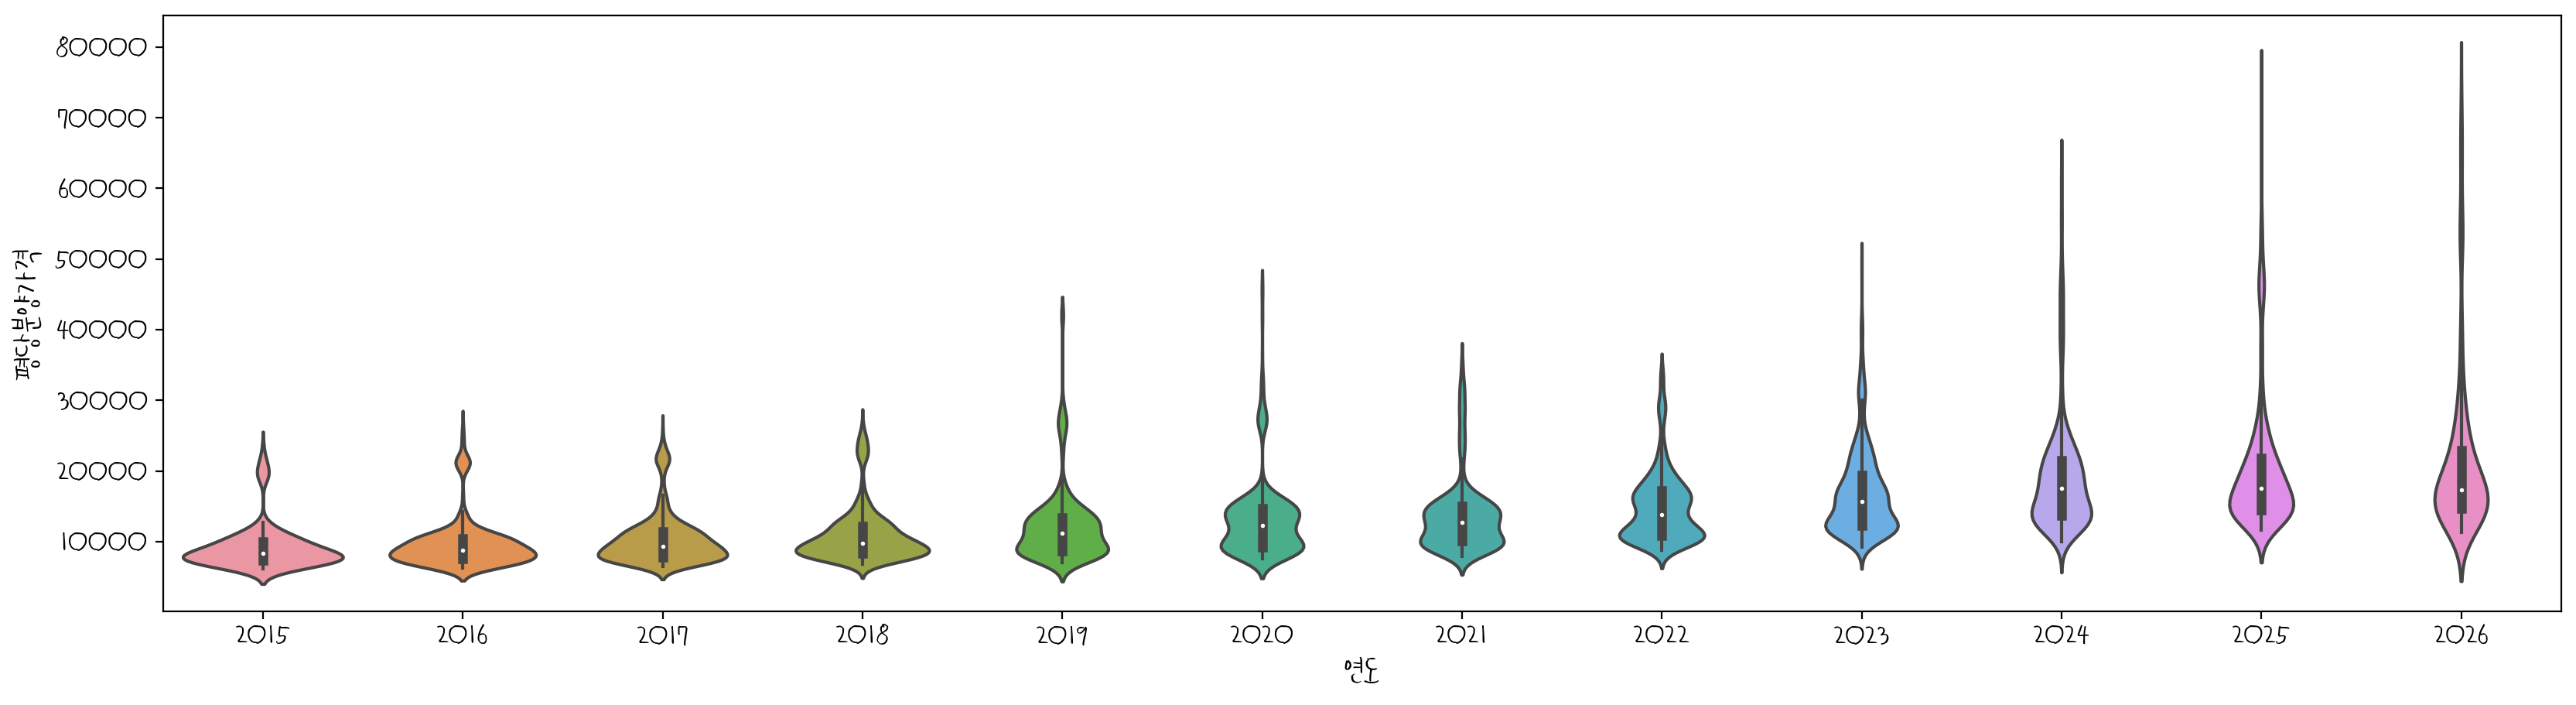

In [57]:
# sns 함수 사용
plt.figure(figsize=(20,5))
sns.violinplot(data=df_last, x='연도', y='평당분양가격')
plt.xlabel('연도', fontsize=15)
plt.ylabel('평당분양가격', fontsize=15)

# 5번

In [92]:
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')

In [93]:
# 구조 변경
new_first = df_first.melt(id_vars='지역', var_name='연도월', value_name='평당분양가격')
new_first.head()

,지역,연도월,평당분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098


In [94]:
# apply를 이용한 데이터 분할
new_first['연도'] = new_first['연도월'].apply(lambda datestr : int(datestr[:4]))
new_first['월'] = new_first['연도월'].apply(lambda datestr : int(datestr[5:-1]))
new_first.head()

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12
1,부산,2013년12월,8111,2013,12
2,대구,2013년12월,8080,2013,12
3,인천,2013년12월,10204,2013,12
4,광주,2013년12월,6098,2013,12


In [95]:
# 필요없는 컬럼 drop
new_first.drop('연도월', axis=1, inplace=True)

In [96]:
new_first['평당분양가격'] = new_first['평당분양가격'].astype('float64')

In [97]:
new_first.rename(columns={'지역':'지역명'}, inplace = True)

In [98]:
new_first.head()

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12


In [99]:
new_last = df_last[df_last['전용면적']=='모든면적']

In [100]:
# 필요없는 컬럼 drop
new_last = new_last.drop('전용면적', axis=1)

In [101]:
new_last.head()

,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
5,인천,2015,10,10437.9
10,경기,2015,10,10355.4
15,부산,2015,10,10269.6
20,대구,2015,10,8850.6


In [102]:
# concat 사용 및 reset_index, 연도/월 sort
df = pd.concat([new_first, new_last]).sort_values(['연도', '월']).reset_index(drop=True)
df

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12
...,...,...,...,...
2528,전북,12714.9,2026,5
2529,전남,12490.5,2026,5
2530,경북,13549.8,2026,5
2531,경남,15450.6,2026,5
